# RUN 15107 

Let's look into trigger 2 data from one of the first HE runs.

In [80]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

In [81]:
path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/15107/'

data_path = path + '*/*'
save_path = path + 'all_info.h5' #'dst.h5'
save_path_clean = path + 'all_info_clean.h5' #'all_info.h5' #'dst.h5'
save_path_summary = path + 'all_info_summary.h5'

files = sorted(glob.glob(data_path + '*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

In [82]:
dst = pd.read_hdf(save_path, 'DST/Events')

In [76]:
print('# events:', len(dst.event.unique()))

clean_dst = dst[(dst.DT > 0) & (dst.DT < 1500)]

print('# events:', len(clean_dst.event.unique()))

# events: 67969


Text(0.5, 0, 'DT (mus)')

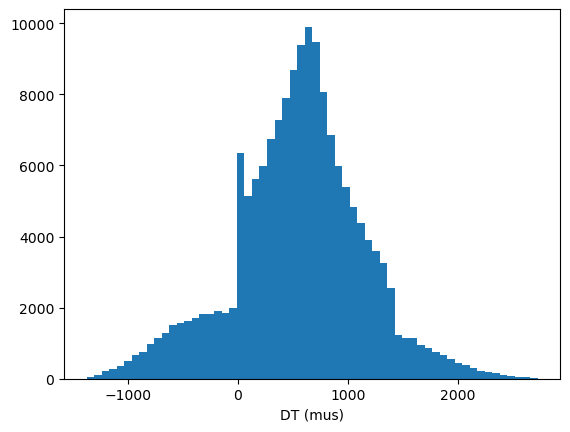

In [6]:
plt.hist(dst.DT, 60)
plt.xlabel('DT (mus)')

Vemos DTs que se salen de la cámara... hacemos cortes 

Text(0.5, 0, 'DT (mus)')

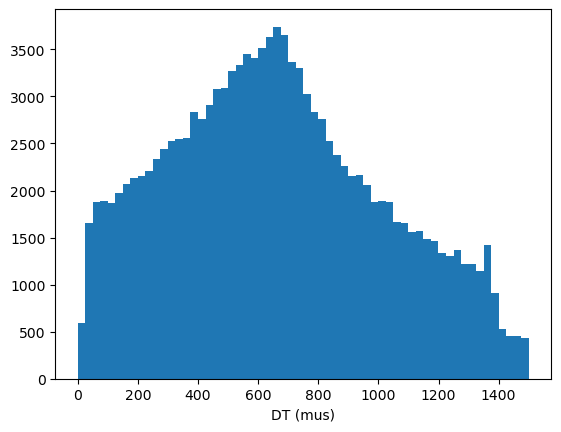

In [7]:
plt.hist(dst[(dst.DT > 0) & (dst.DT < 1500)].DT, 60)
plt.xlabel('DT (mus)')

In [8]:
.copy()

# events: 61712


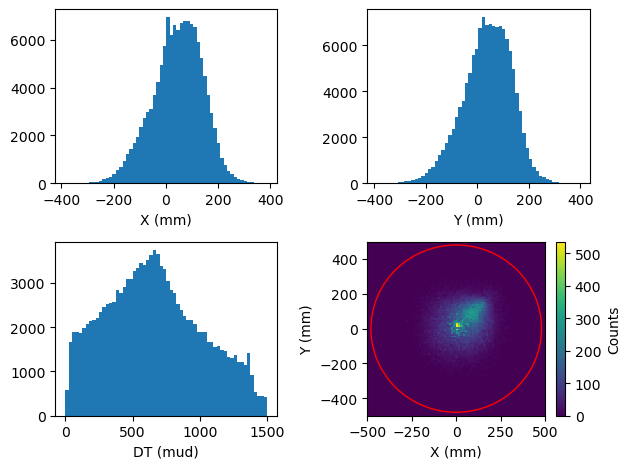

In [10]:
plt.subplot(2, 2, 1)
plt.hist(clean_dst.X, 60)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(clean_dst.Y, 60)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(clean_dst.DT, 60)
plt.xlabel('DT (mud)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(clean_dst.X, clean_dst.Y, bins=100, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()

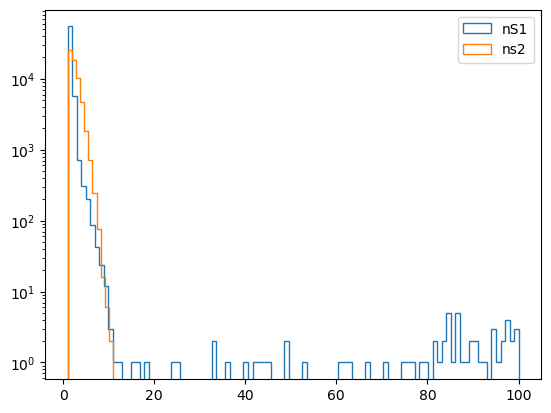

In [11]:
nsignal = clean_dst[['event', 'nS1', 'nS2']].drop_duplicates()
plt.hist(nsignal.nS1, max(nsignal.nS1), range=(min(nsignal.nS1), max(nsignal.nS1)), histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, max(nsignal.nS2), range=(min(nsignal.nS2), max(nsignal.nS2)), histtype='step', label = 'ns2')
plt.yscale('log')
plt.legend()

No nos interesa, quitamos los eventos con más de 15 S1

In [12]:
clean_dst = clean_dst[clean_dst.nS1 < 15]

In [13]:
print('# events:', len(clean_dst.event.unique()))

# events: 61647


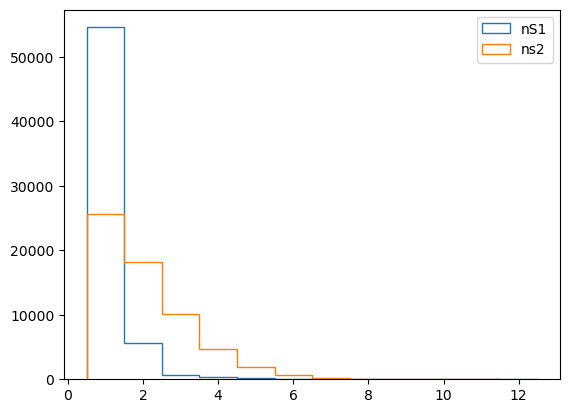

In [14]:
nsignal = clean_dst[['event', 'nS1', 'nS2']].drop_duplicates()
plt.hist(nsignal.nS1, max(nsignal.nS1), range=(0.5, max(nsignal.nS1) + 0.5), histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, max(nsignal.nS2), range=(0.5, max(nsignal.nS2) + 0.5), histtype='step', label = 'ns2')
plt.legend()

Seleccionamos los eventos con un solo S1 para ver cómo son sus S2

In [15]:
ones1_dst = clean_dst[(clean_dst.nS1 == 1)]
ones1_dst = clean_dst[(clean_dst.nS2 == 1)]

In [16]:
print('# events:', len(ones1_dst.event.unique()))

# events: 25627


Text(0.5, 0, 'S2 energy (pes)')

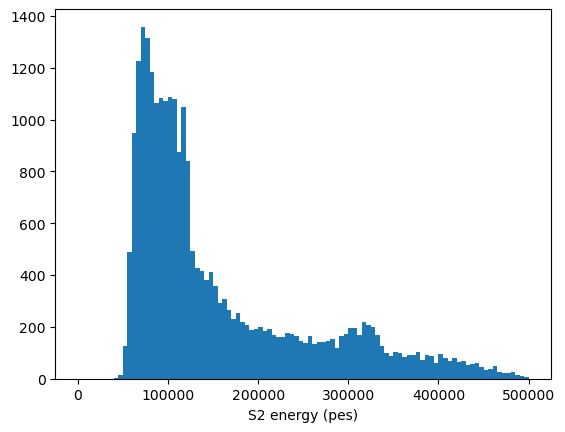

In [17]:
plt.hist(ones1_dst.S2e, 100, (0, 500000))
plt.xlabel('S2 energy (pes)')

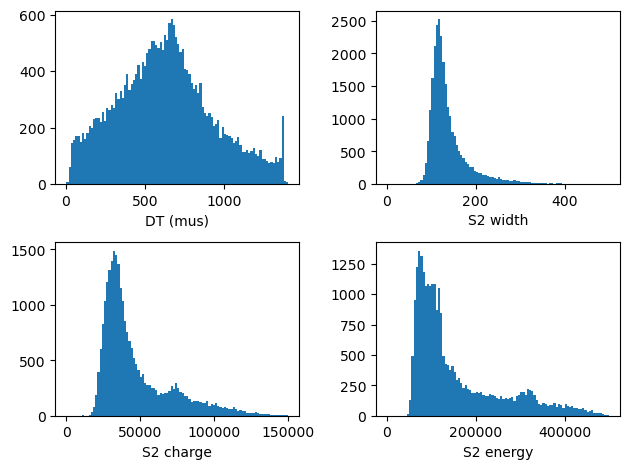

In [18]:
plt.subplot(2, 2, 1)
plt.hist(ones1_dst.DT, 100)
plt.xlabel('DT (mus)')

plt.subplot(2, 2, 2)
plt.hist(ones1_dst.S2w, 100, (0, 500))
plt.xlabel('S2 width')

# plt.subplot(2, 2, 3)
# plt.hist(ones1_dst.S2h, 100, (0, 20000))
# plt.xlabel('S2 height')

plt.subplot(2, 2, 3)
plt.hist(ones1_dst.S2q, 100, (0, 150000))
plt.xlabel('S2 charge')

plt.subplot(2, 2, 4)
plt.hist(ones1_dst.S2e, 100, (0, 500000))
plt.xlabel('S2 energy')

plt.tight_layout()

In [19]:
dst.columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms'],
      dtype='object')

energia corregida

anchura x, y, z
baricentros

numero hits

In [30]:
s2e_dst = ones1_dst[(ones1_dst.S2e > 200000) & (ones1_dst.S2e < 400000)]

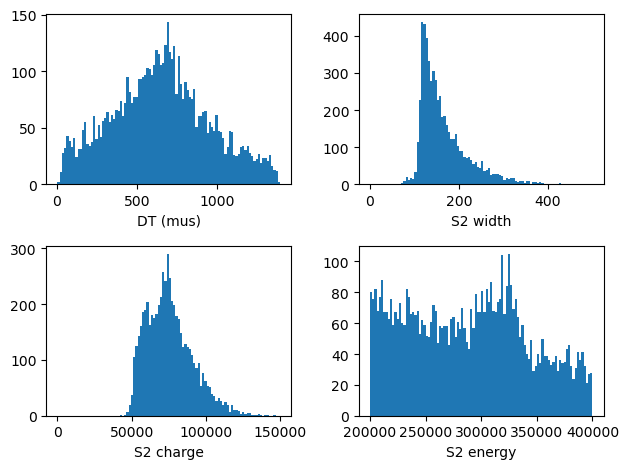

In [31]:
plt.subplot(2, 2, 1)
plt.hist(s2e_dst.DT, 100)
plt.xlabel('DT (mus)')

plt.subplot(2, 2, 2)
plt.hist(s2e_dst.S2w, 100, (0, 500))
plt.xlabel('S2 width')

# plt.subplot(2, 2, 3)
# plt.hist(s2e_dst.S2h, 100, (0, 20000))
# plt.xlabel('S2 height')

plt.subplot(2, 2, 3)
plt.hist(s2e_dst.S2q, 100, (0, 150000))
plt.xlabel('S2 charge')

plt.subplot(2, 2, 4)
plt.hist(s2e_dst.S2e, 100, (200000, 400000))
plt.xlabel('S2 energy')

plt.tight_layout()

Text(0, 0.5, 'S2 energy (pes)')

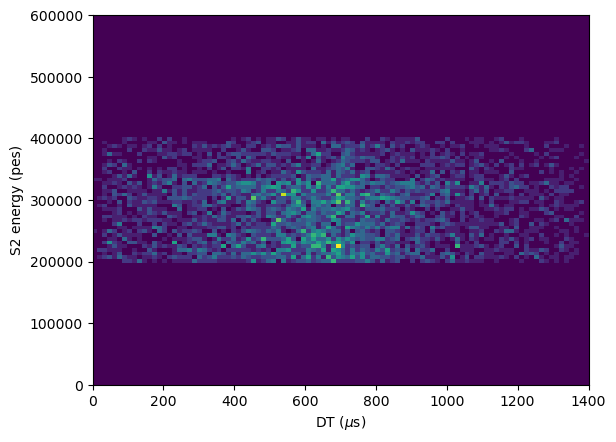

In [32]:
hist = plt.hist2d(s2e_dst.DT, s2e_dst.S2e, bins = 100, range = ((0, 1400), (0, 600000)), cmap='viridis')
plt.xlabel(r'DT ($\mu$s)')
plt.ylabel('S2 energy (pes)')

Text(0, 0.5, 'DT$_{rms}^2$ ($\\mu$s$^2$)')

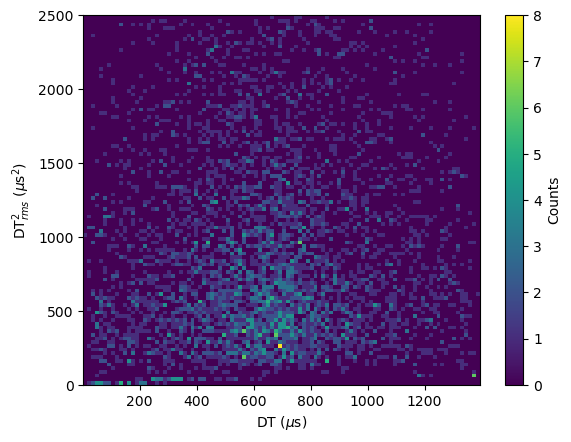

In [33]:
def line(x, m, b):
    return m * x + b

m_sup, b_sup = 0.1, 50

m_inf, b_inf = 0.03, 15


hist = plt.hist2d(s2e_dst.Z, (s2e_dst.Zrms) ** 2, bins=100, range=((min(s2e_dst.Z), max(s2e_dst.Z)), (0, 2500)), cmap='viridis')

plt.colorbar(hist[3], label='Counts')

# x = np.arange(0, 2000, 10)
# y_sup = line(x, m_sup, b_sup)
# y_inf = line(x, m_inf, b_inf)
# plt.plot(x, y_sup, 'r')
# plt.plot(x, y_inf, 'r')
plt.xlabel('DT ($\mu$s)')
plt.ylabel(r'DT$_{rms}^2$ ($\mu$s$^2$)')

In [34]:
# band_dst = s2e_dst[((s2e_dst.Zrms ** 2 < line(s2e_dst.Z, m_sup, b_sup)) & (s2e_dst.Zrms ** 2 > line(s2e_dst.Z, m_inf, b_inf)))]

# hist = plt.hist2d(band_dst.Z, (band_dst.Zrms) ** 2, bins=100, range=((min(band_dst.Z), max(band_dst.Z)), (0, 50)), cmap='viridis')

# plt.colorbar(hist[3], label='Counts')
# plt.xlabel('DT ($\mu$s)')
# plt.ylabel(r'DT$_{rms}^2$ ($\mu$s$^2$)')

In [35]:
# plt.subplot(2, 2, 1)
# plt.hist(band_dst.DT, 100)
# plt.xlabel('DT (mus)')

# plt.subplot(2, 2, 2)
# plt.hist(band_dst.S2w, 100, (0, 200))
# plt.xlabel('S2 width')

# # plt.subplot(2, 2, 3)
# # plt.hist(band_dst.S2h, 100, (0, 20000))
# # plt.xlabel('S2 height')

# plt.subplot(2, 2, 3)
# plt.hist(band_dst.S2q, 100, (0, 10000))
# plt.xlabel('S2 charge')

# plt.subplot(2, 2, 4)
# plt.hist(band_dst.S2e, 100, (0, 10000))
# plt.xlabel('S2 energy (pe)')

# plt.tight_layout()

In [36]:
from invisible_cities.reco.corrections import read_maps, apply_all_correction, get_df_to_z_converter, get_normalization_factor, maps_coefficient_getter, correct_lifetime_, correct_geometry_
from invisible_cities.types.symbols import NormStrategy

from typing          import Any
def identity(x : Any) -> Any:
    return x

In [37]:
map_path = path + 'map_MC_4bar_15063.h5'
maps = read_maps(map_path)

In [38]:
save_path_clean

'/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/15107/all_info_clean.h5'

In [39]:
# normalization   = get_normalization_factor(maps, NormStrategy.kr, '')
# get_xy_corr_fun = maps_coefficient_getter(maps.mapinfo, maps.e0)
# get_lt_corr_fun = maps_coefficient_getter(maps.mapinfo, maps.lt)

# #for apply temp = False
# e0evol_vs_t = lambda x : np.ones_like(x)
# ltevol_vs_t = lambda x : np.ones_like(x)


# geo_factor = correct_geometry_(get_xy_corr_fun(X,Y) * e0evol_vs_t(t))
# lt_factor  = correct_lifetime_(Z, get_lt_corr_fun(X,Y) * ltevol_vs_t(t))
# factor     = geo_factor * lt_factor * normalization

In [40]:
get_coef  = apply_all_correction( maps
                                    , apply_temp = False
                                    , norm_strat = NormStrategy.kr)
time_to_Z = get_df_to_z_converter(maps) if maps.t_evol is not None else identity

### Correct directly on peaks

In [41]:
s2e_dst['Ec']  = s2e_dst.S2e * get_coef(s2e_dst.X, s2e_dst.Y, s2e_dst.Z, s2e_dst.DT)

/scratch/11451332/ipykernel_885656/3491152889.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s2e_dst['Ec']  = s2e_dst.S2e * get_coef(s2e_dst.X, s2e_dst.Y, s2e_dst.Z, s2e_dst.DT)


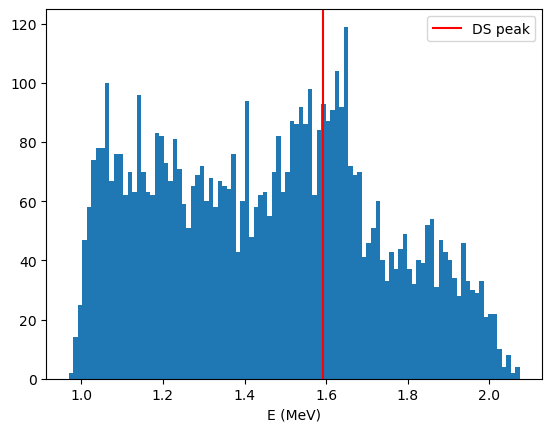

In [42]:
plt.hist(s2e_dst.Ec, 100)
plt.axvline(1.592, c='r', label = 'DS peak')
plt.xlabel('E (MeV)')
plt.legend()

In [43]:
ds_dst = s2e_dst[(s2e_dst.Ec > 1.4) & (s2e_dst.Ec < 1.8)]

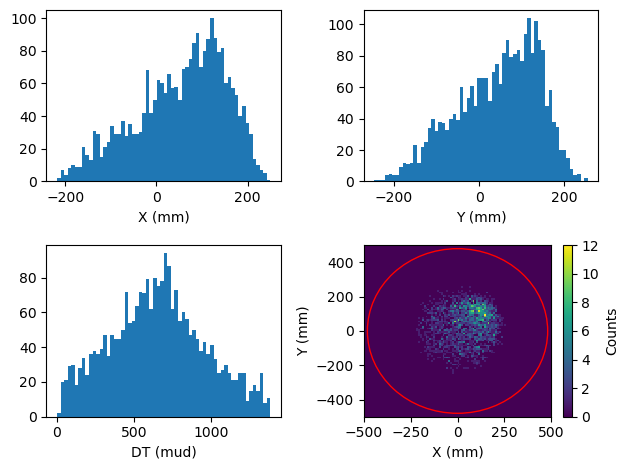

In [44]:
plt.subplot(2, 2, 1)
plt.hist(ds_dst.X, 60)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(ds_dst.Y, 60)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(ds_dst.DT, 60)
plt.xlabel('DT (mud)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(ds_dst.X, ds_dst.Y, bins=100, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()

## Correct on hits

In [45]:
recohits = pd.read_hdf(save_path_clean, 'RECO/Events')

In [46]:
len(recohits.event.unique())

5261

In [78]:
len(recohits.event.unique())

5261

In [47]:
X, Y, Z, t = recohits.X, recohits.Y, recohits.Z, recohits.time
corr = get_coef(X, Y, Z, t)
recohits['Ec_hand']  = recohits.E * corr

recohits['Z_hand'] = time_to_Z(Z)

E_corr_hand = recohits.groupby('event').Ec_hand.sum()

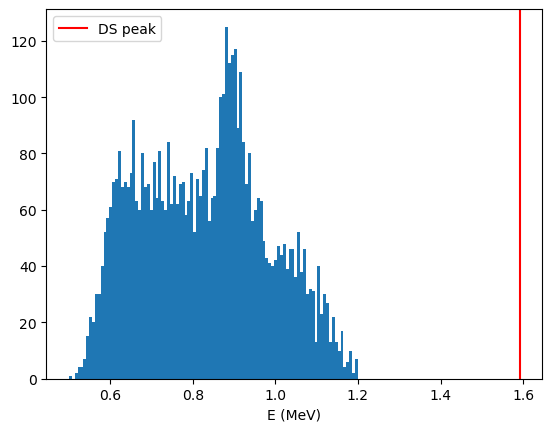

In [48]:
plt.hist(recohits.groupby('event').Ec.sum(), 100, (0.5, 1.2))
plt.axvline(1.592, c='r', label = 'DS peak')
plt.xlabel('E (MeV)')
plt.legend()

In [49]:
from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

#trashy function, very hard coded
def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
    plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
    plt.plot(fit_x, yfit, 'r-', label = legend_string)
    plt.legend()
    plt.xlabel('E (MeV)')
    if density:
        plt.ylabel('Probability density (1 / MeV)')
    else:
        plt.ylabel('Events')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R

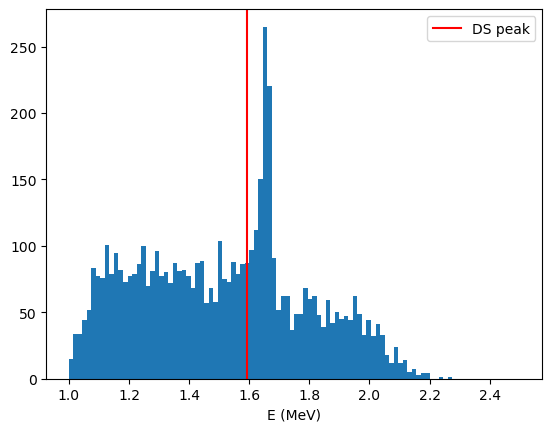

In [50]:
plt.hist(E_corr_hand, 100, (1, 2.5))
plt.axvline(1.592, c='r', label = 'DS peak')
plt.xlabel('E (MeV)')
plt.legend()

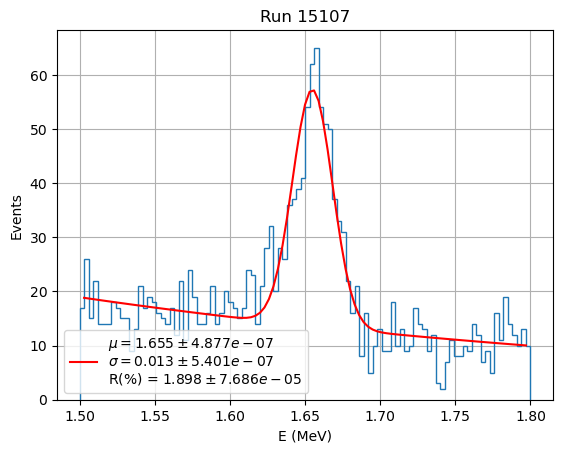

(array([4.36813216e+01, 1.65496849e+00, 1.33410886e-02, 4.69717480e+02,
        4.67133771e-01]),
 1.8982755944364524)

In [51]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

fit_and_plot_peaks_resolution(E_corr_hand, peak_fit, 100, rang, rang, initial_params, bounds, 'Run 15107', density = False)

In [52]:
recohits = recohits.merge(recohits.groupby('event').apply(lambda x: (x.X * x.Ec_hand).sum() / x.Ec_hand.sum()).rename('X_bary'), on = 'event')
recohits = recohits.merge(recohits.groupby('event').apply(lambda x: (x.Y * x.Ec_hand).sum() / x.Ec_hand.sum()).rename('Y_bary'), on = 'event')
recohits = recohits.merge(recohits.groupby('event').apply(lambda x: (x.Z * x.Ec_hand).sum() / x.Ec_hand.sum()).rename('Z_bary'), on = 'event')


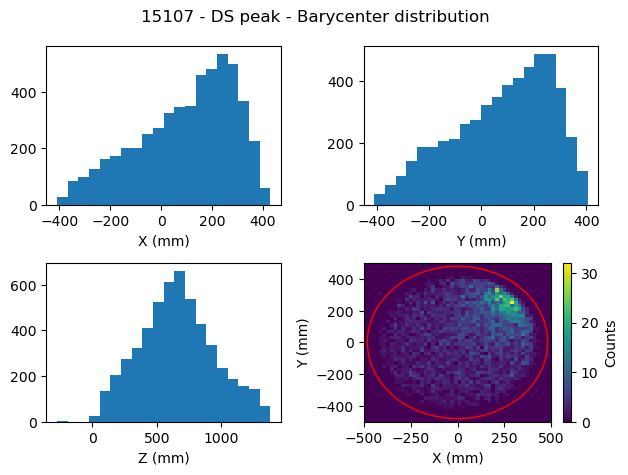

In [53]:
recobary = recohits[['event', 'X_bary', 'Y_bary', 'Z_bary']].drop_duplicates()

plt.suptitle('15107 - DS peak - Barycenter distribution')
plt.subplot(2, 2, 1)
plt.hist(recobary.X_bary, 20)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(recobary.Y_bary, 20)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(recobary.Z_bary, 20)
plt.xlabel('Z (mm)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(recobary.X_bary, recobary.Y_bary, bins=50, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()

In [54]:
xcut, ycut, rcut = 0, 0, 350
recohits_q = recohits[(recohits.X_bary > xcut) & (recohits.Y_bary > ycut) & (np.sqrt(recohits.X_bary ** 2 + recohits.Y_bary **2) < rcut )]

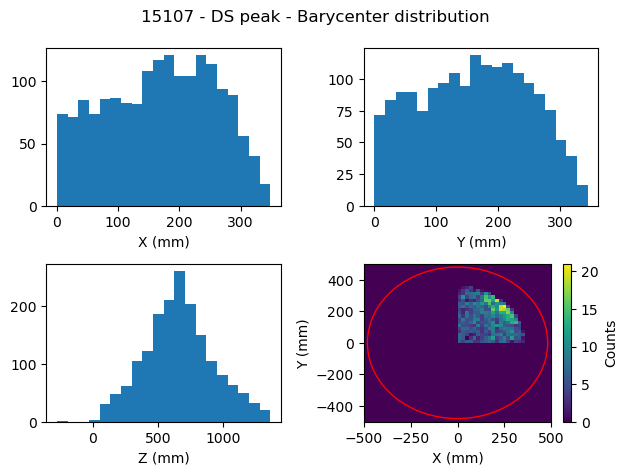

In [55]:
recobary_q = recohits_q[['event', 'X_bary', 'Y_bary', 'Z_bary']].drop_duplicates()

plt.suptitle('15107 - DS peak - Barycenter distribution')
plt.subplot(2, 2, 1)
plt.hist(recobary_q.X_bary, 20)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(recobary_q.Y_bary, 20)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(recobary_q.Z_bary, 20)
plt.xlabel('Z (mm)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(recobary_q.X_bary, recobary_q.Y_bary, bins=50, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()

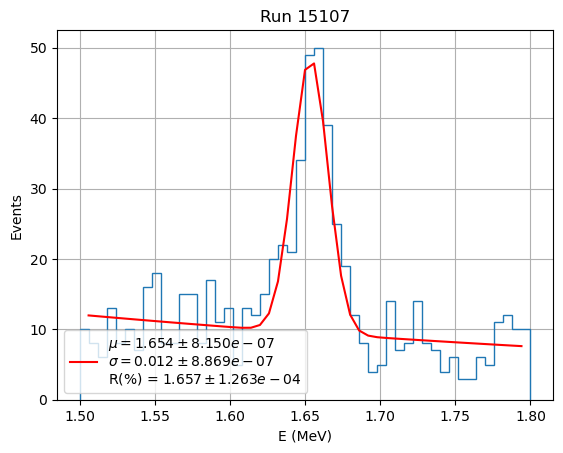

(array([3.91358423e+01, 1.65359511e+00, 1.16327805e-02, 1.27802881e+02,
        6.36062296e-01]),
 1.65657871723616)

In [56]:
fit_and_plot_peaks_resolution(recohits_q.groupby('event').Ec_hand.sum(), peak_fit, 50, rang, rang, initial_params, bounds, 'Run 15107', density = False)

In [57]:
ds_reco = recohits[np.isin(list(recohits.event), E_corr_hand[(E_corr_hand > 1.5) & (E_corr_hand < 1.8)].index)]

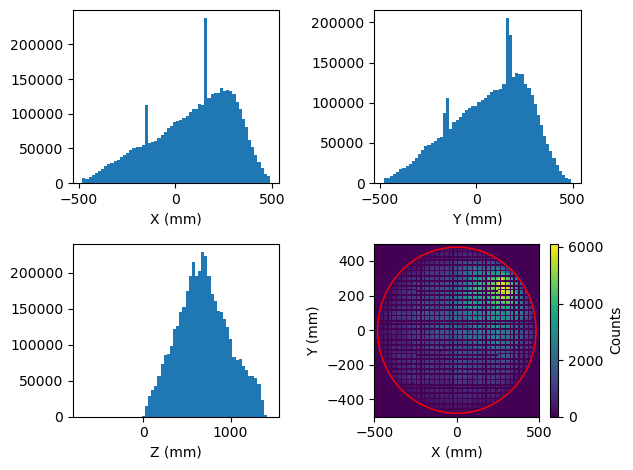

In [58]:
plt.subplot(2, 2, 1)
plt.hist(ds_reco.X, 60)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(ds_reco.Y, 60)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(ds_reco.Z, 60)
plt.xlabel('Z (mm)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(ds_reco.X, ds_reco.Y, bins=100, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()

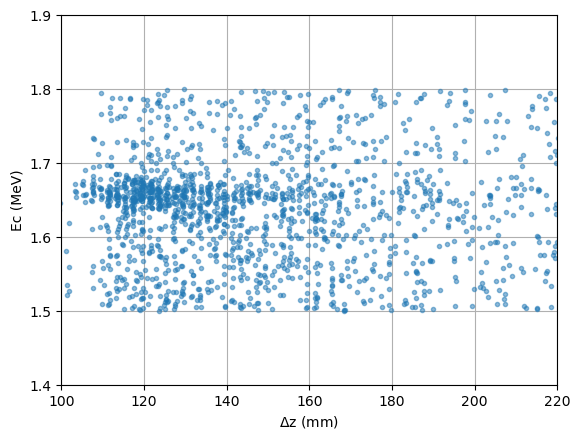

In [59]:
plt.plot(ds_reco.groupby('event').Z.max() - ds_reco.groupby('event').Z.min(), ds_reco.groupby('event').Ec_hand.sum(), '.', alpha = 0.5)
plt.xlim((100, 220))
plt.ylim((1.4, 1.9))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

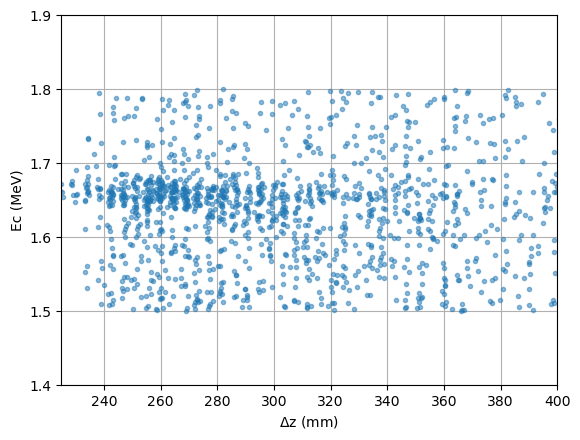

In [66]:
plt.plot(ds_reco.groupby('event').Z_hand.max() - ds_reco.groupby('event').Z_hand.min(), ds_reco.groupby('event').Ec_hand.sum(), '.', alpha = 0.5)
plt.xlim((225, 400))
plt.ylim((1.4, 1.9))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

In [72]:
(ds_reco.Z / ds_reco.Z_hand).unique()

array([0.45966664, 0.45966664, 0.45966664])